# Exploring Uncertainty in Climate Model Precipitation

There are several kinds of scientific uncertainty that arise when working with long-term projections of future climates:

1. Model Uncertainty, which illustrates the differences between different models (namely, how model physics, settings, or parameters can change the outcome)
2. Scenario Uncertainty, which illustrates the differences in outcomes between end-of-century emissions targets
3. Internal Variability, which represents the variations inherent within the climate system itself

This notebook is divided into two analysis components which explore the following, respectively:
- <b>Model Uncertainty</b> in the Cal-Adapt: Analytics Engine by focusing on <b>extreme precipitation trends</b> across simulations. We also compare the suite of models currently available in the Cal-Adapt Data Catalog to the full set of CMIP6 models to illustrate the differences between our models and all available models.
- <b>Internal Variability</b> in the Cal-Adapt: Analytics Engine by focusing on <b>extreme precipitation trends</b> across <i>ensemble members</i>\*. We also show where the Cal-Adapt: Analytics Engine <i>downscaled</i>\** ensemble members fit within the larger ensemble.

\* Ensemble member: When a given model is run multiple times, we call the group of runs an <i>ensemble</i>. Each ensemble member represents a distinct realization featuring its own combination of model parameters. We call the the differences between ensemble members <b>Internal Variability</b>. 

\** Downscaling: One ensemble member from each Cal-Adapt: Analytics Engine model was used to provide input data for the Weather Research and Forecasting (WRF) Model, allowing us to capture much smaller-scale details than the CMIP6 models. 

(want to insert the table from my storyboard here)

For this demo, we choose to focus on <b>Sonoma County</b>, which is vulnerable to flooding along the Russian River.

---

<b>Story</b>

As a user, I want to understand when <span style="color:red"><b>it is appropriate to use only the downscaled Analytics Engine models to draw conclusions about extreme precipitation statistics</b></span>, by visualizing the differences across models and within model ensembles. In this notebook we will show you:

1. A range of possibilities for the end of century across all available CMIP6 models
2. Which models are provided in the Analytics Engine as compared to the rest of CMIP6 models
3. The results for each model's set of ensemble members
4. Where the downscaled results for a given model fit within the larger ensemble

Part 0 -- Setup the notebook, including CMIP6 processing code

Part 1 -- Model Uncertainty:
- Part 1.1 -- Get and process the CMIP6 data; compute statistics
- Part 1.2 -- Visualize annual maximum precipitation through end-of-century across all CMIP6 models
- Part 1.3 -- Highlight the Analytics Engine models within this spread
- Part 1.4 -- Show the difference between end-of-century (2071-2100) and present-day (1981-2010) extreme precipitation across all models

Part 2 -- Internal Variability:
- Part 2.1 -- Get and process the Analytics Engine models; compute statistics
- Part 2.2 -- Visualize annual maximum precipitation through end-of-century across each ensemble member, with the downscaled data and its corresponding ensemble member highlighted.
- Part 2.3 -- Show the difference between end-of-century (2071-2100) and present-day (1981-2010) extreme precipitation across all ensemble members



# Part 0: Setup

In [1]:
%%capture
!pip install -r requirements.txt
!pip install xmip
# !pip install seaborn
import climakitae as ck
# import seaborn as sns
import xarray as xr
import pandas as pd
import numpy as np
import datetime
import intake
import dask
import matplotlib as mpl
import matplotlib.pyplot as plt
import xesmf as xe
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore")
import holoviews as hv

hv.extension('bokeh')

In [2]:
%%capture
from xmip.preprocessing import (
    rename_cmip6
) # will figure out how to avoid later

def cf_to_dt(ds):
    """
    convert cftime to pandas datetime -
    some GCMs have some wacky calendars
    """
    ds = ds.copy()
    if (
        type(ds.indexes['time']) not in 
        [pd.core.indexes.datetimes.DatetimeIndex]
    ): 
        datetimeindex = ds.indexes['time'].to_datetimeindex()
        ds['time'] = datetimeindex
    return ds

def calendar_align(ds):
    '''
    different models have different calendars
    (some no leap, some 360 day). this results
    in a huge dataset with lots of empty
    values in time when concatenated. 
    the following function sets the day for all monthly
    values to the 1st of each month -
    WARNING this can impact functions which use
    the number of days in each month (eg
    precip flux to total monthly accumulation).
    I can't find a nice way around this.
    '''
    ds['time'] = pd.to_datetime(ds.time.dt.strftime('%Y-%m'))
    return ds

def precip_flux_to_total(ds):
    """
    converts precip flux units 
    (kg m-2 s-1) to total precip
    per month (mm)
    NOTE: assumes regular calendar
    """
    ds = ds.copy()
    ds_attrs = ds.attrs
    days_month = ds.time.dt.days_in_month
    seconds_month = 86400*days_month
    ds = ds*seconds_month
    ds.attrs = ds_attrs
    ds.pr.attrs["units"] = 'mm'
    return ds


def wrapper(ds):
    ds_simulation = ds.attrs["source_id"]
    ds_scenario = ds.attrs["experiment_id"]
    ds_freq = ds.attrs["frequency"]
    
    ds = ds.copy()
    ds = rename_cmip6(ds)
    # ds = broadcast_lonlat(ds)
    # ds = replace_x_y_nominal_lat_lon(ds)
    ds = cf_to_dt(ds)
    if ds_freq in ('mon'):
        ds = calendar_align(ds)
    ds = precip_flux_to_total(ds)
    ds = ds.drop_vars(["lon","lat"],
                     errors="ignore")
    ds = ds.assign_coords({'simulation' : 
                           ds_simulation,
                          'scenario' :
                          ds_scenario})
    ds = ds.squeeze(drop=True)
    
    return ds

In [3]:
shp_cat = intake.open_catalog(
    "https://cadcat.s3.amazonaws.com/parquet/catalog.yaml")

us_states = shp_cat.states.read()
us_counties = shp_cat.counties.read()
us_watersheds = shp_cat.huc8.read()

shp_cat = None

col = intake.open_esm_datastore("https://cadcat.s3.amazonaws.com/tmp/cmip6-regrid.json")


In [123]:
class cmip_opt():
    def __init__(self, variable='tas', 
                  area_subset='states', 
                 location='California',
                 timescale='monthly',
                area_average=True):
        self.variable = variable
        self.area_subset = area_subset
        self.location = location
        self.area_average = area_average
        self.timescale = timescale
        
    def cmip_clip(self, ds):
        ds = ds.copy()
        variable = self.variable
        location = self.location
        area_average = self.area_average
        area_subset = self.area_subset
        timescale = self.timescale
        
        to_drop = [v for v in list(
                    ds.data_vars) 
                  if v != variable]
        ds = ds.drop_vars(to_drop)
        ds = clip_region(ds,area_subset,location)
        if area_average:
            ds = area_wgt_average(ds)
        return ds
    
def clip_region(ds,area_subset,location):
    """
    clips CMIP6 dataset using a polygon.
    ds is the dataset
    state is a string ("California")
    (check catalog for other names)
    opt = 'True' to burn in all cells
    which touch the boundary (keep as False)
    """
    ds = ds.copy()
    ds = ds.rio.write_crs(4326)
    
    if 'counties' in area_subset:
        ds_region = us_counties[us_counties.NAME 
                    == location].geometry
    elif 'states' in area_subset:
        ds_region = us_states[us_states.NAME 
                    == location].geometry
        
    try:
        ds = ds.rio.clip(
            geometries=ds_region,crs=4326, drop=True,
        all_touched=False)
    except: 
        #if no grid centers in region
        # instead select all cells which 
        # intersect the region
        print('USER NOTE: Selecting all cells which intersect region')
        ds = ds.rio.clip(
            geometries=ds_region,crs=4326, drop=True,
        all_touched=True)
        
    return ds

def area_wgt_average(ds):
    ds = ds.copy()
    weights = np.cos(np.deg2rad(ds.y))
    weights.name = "weights"
    ds_weighted = ds.weighted(weights)
    ds = ds_weighted.mean(("x","y"))
    return ds

def drop_member_id(dset_dict): 
    """Drop member_id coordinate/dimensions 
    Args: 
        dset_dict (dict): dictionary in the format {dataset_name:xr.Dataset}
    """
    for dname, dset in dset_dict.items():
        if "member_id" in dset.coords: 
            dset = dset.isel(member_id=0).drop("member_id") # Drop coord
            dset_dict.update({dname: dset}) # Update dataset in dictionary
    return dset_dict

## set options for CMIP6 data

In [5]:
copt = cmip_opt()
copt.variable = 'pr'
copt.area_subset = 'states' 
copt.location = 'California'
copt.area_average = False
copt.timescale = 'monthly'

sim_names = {
    "CESM2": "cesm2",
    "CNRM-ESM2-1": "cnrm-esm2-1",
    "EC-Earth3-Veg": "ec-earth3-veg",
    "FGOALS-g3": "fgoals-g3"
}

cmip_names = list(sim_names.keys())

cae_colors_list = [
    '#4477AA', '#66CCEE',
    '#228833', '#EE6677',
    '#AA3377' ,
]

# Part 1: Model Uncertainty

## Part 1.1: Get and process data

### First the downscaled Cal-Adapt data

In [24]:
app = ck.Application()
app.selections.scenario_historical=['Historical Climate']
app.selections.scenario_ssp=['SSP 3-7.0 -- Business as Usual']
app.selections.append_historical = True
app.selections.area_average = copt.area_average
app.selections.variable = 'Precipitation (total)'
app.selections.time_slice = (1981, 2100)
app.selections.resolution = '45 km'
app.location.area_subset='states'
app.location.cached_area = 'CA'

wrf_ds = app.retrieve()

renamed_ds_list = []

for cn,wn in sim_names.items():
    renamed_ds_list.append(
        wrf_ds.sel(simulation=wn
                  ).squeeze().assign_coords(
            {'simulation' : cn}))
    
wrf_ds = xr.concat(renamed_ds_list,dim='simulation')

In [152]:
hist_wrf = wrf_ds.sel(
    time=slice('1981','2010'))
ssp_wrf = wrf_ds.sel(
    time=slice('2071','2100'))

In [26]:
# def quants_and_deltas(ds,q):
    
#     q = q/100
#     hist_percentile = ds.sel(
#     time=slice('1981','2010')).chunk(dict(
#     time=-1)).quantile(q,
#     dim='time').compute()

#     ssp_percentile = ds.sel(
#     time=slice('2071','2100')).chunk(dict(
#     time=-1)).quantile(q,
#     dim='time').compute()

#     hist_mean = ds.sel(
#     time=slice('1981','2010')
#     ).mean().compute()

#     ssp_mean = ds.sel(
#     time=slice('2071','2100')
#     ).mean().compute()

#     delta_percentile = (ssp_percentile 
#                          - hist_percentile).compute()

#     delta_mean = (ssp_mean 
#                     - hist_mean).compute()
    
#     return (hist_mean, hist_percentile, 
#             ssp_mean, ssp_percentile,
#             delta_mean, delta_percentile)



In [153]:
# mean and 99th percentile all models

cads_hist_percentile = hist_wrf.chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute().squeeze()

cads_ssp_percentile = ssp_wrf.chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute().squeeze()

cads_hist_mean = hist_wrf.mean(dim='time').compute()

cads_ssp_mean = ssp_wrf.mean(dim='time').compute()

cads_delta_percentile = (cads_ssp_percentile 
                         - cads_hist_percentile).compute()

cads_delta_mean = (cads_ssp_mean 
                    - cads_hist_mean).compute()

In [67]:
import cartopy.feature as cfeature

scale = '110m'
states110 = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale=scale,
            facecolor='none',
            edgecolor='k')

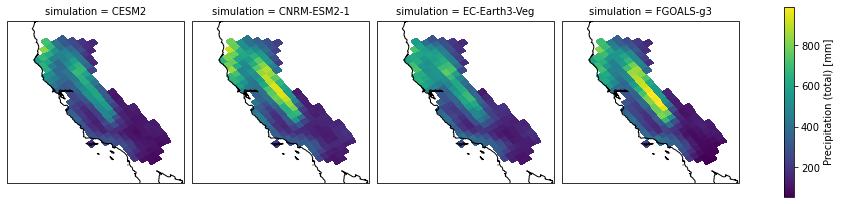

In [69]:

# This is the map projection we want to plot *onto*
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = cads_hist_percentile.plot(
    transform=wrf_proj,  # the data's projection
    col="simulation",
    col_wrap=4,  # multiplot settings
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

# We have to set the map's options on all axes
for ax in p.axes.flat:
    ax.coastlines()
    # ax.add_feature(states110, zorder=1, linewidth=1.5)

    # ax.set_extent([-80, -60, 30, 46])

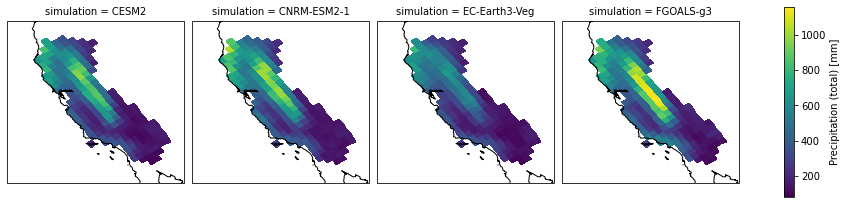

In [63]:

# This is the map projection we want to plot *onto*
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = cads_ssp_percentile.plot(
    transform=wrf_proj,  # the data's projection
    col="simulation",
    col_wrap=4,  # multiplot settings
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

# We have to set the map's options on all axes
for ax in p.axes.flat:
    ax.coastlines()
    # ax.set_extent([-80, -60, 30, 46])

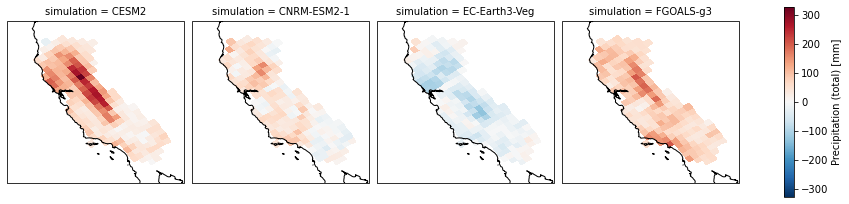

In [109]:

# This is the map projection we want to plot *onto*
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = cads_delta_percentile.plot(
    transform=wrf_proj,  # the data's projection
    col="simulation",
    col_wrap=4,  # multiplot settings
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

# We have to set the map's options on all axes
for ax in p.axes.flat:
    ax.coastlines()
    # ax.set_extent([-80, -60, 30, 46])

In [154]:
hist_wrf_pool = hist_wrf.stack(index=['simulation','time'])
ssp_wrf_pool = ssp_wrf.stack(index=['simulation','time'])

In [161]:
hist_wrf_pool_perc = hist_wrf_pool.chunk(
    dict(index=-1)).quantile([.99],
    dim='index').compute().squeeze()

ssp_wrf_pool_perc = ssp_wrf_pool.chunk(
    dict(index=-1)).quantile([.99],
    dim='index').compute().squeeze()

delta_wrf_pool_perc = (ssp_wrf_pool_perc
                       - hist_wrf_pool_perc) 


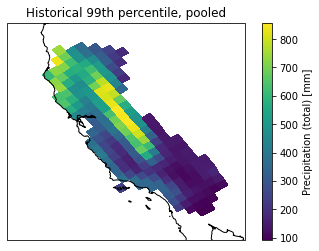

In [169]:
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = hist_wrf_pool_perc.plot(
    transform=wrf_proj,  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('Historical 99th percentile, pooled')
plt.show()

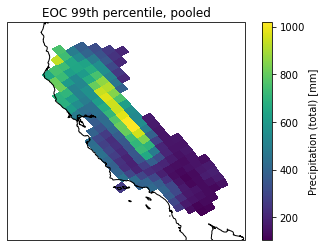

In [170]:
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = ssp_wrf_pool_perc.plot(
    transform=wrf_proj,  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('EOC 99th percentile, pooled')
plt.show()

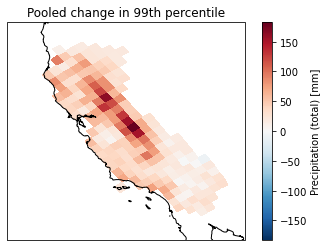

In [166]:
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = delta_wrf_pool_perc.plot(
    transform=wrf_proj,  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('Pooled change in 99th percentile')
plt.show()

In [ ]:
# # mean and 99th percentile all models

# cads_pool_hist_perc = wrf_pool.sel(
#     time=slice('1981','2010')).chunk(dict(
#     index=-1)).quantile([.99],
#     dim='time').compute().squeeze()

# cads_pool_ssp_percentile = wrf_ds.sel(
#     time=slice('2071','2100')).chunk(dict(
#     time=-1)).quantile([.99],
#     dim='time').compute().squeeze()

# cads_hist_mean = wrf_ds.sel(
#     time=slice('1981','2010')
#     ).mean(dim='time').compute()

# cads_ssp_mean = wrf_ds.sel(
#     time=slice('2071','2100')
#     ).mean(dim='time').compute()

# cads_delta_percentile = (cads_ssp_percentile 
#                          - cads_hist_percentile).compute()

# cads_delta_mean = (cads_ssp_mean 
#                     - cads_hist_mean).compute()

In [133]:
cads_delta_percentile_mmm = cads_delta_percentile.mean(dim="simulation")
cads_delta_percentile_mms = cads_delta_percentile.std(dim="simulation")

Text(0.5, 1.0, 'Multi-model mean change in 99th percentile')

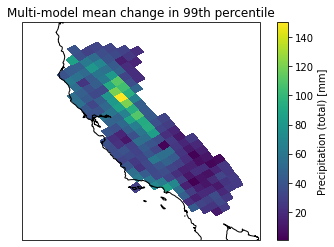

In [136]:
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = abs(cads_delta_percentile_mmm).plot(
    transform=wrf_proj,  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('Multi-model mean change in 99th percentile')

Text(0.5, 1.0, 'Multi-model standard deviation in 99th percentile')

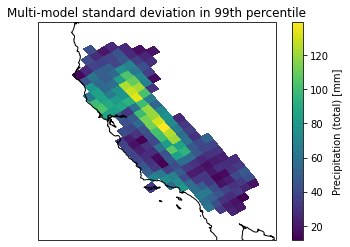

In [135]:
wrf_proj = ccrs.LambertConformal(central_longitude=-70, 
                                 central_latitude=38,
                                standard_parallels=(30,60))

p = cads_delta_percentile_mms.plot(
    transform=wrf_proj,  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('Multi-model standard deviation in 99th percentile')

### Now the CMIP6 data

In [112]:
# grab data from the cmip6 archive
cat = col.search(
    table_id = "Amon",
    variable_id = copt.variable,
    experiment_id = ["historical","ssp370"],
    member_id = "r1i1p1f1",
    require_all_on="source_id"
).search(activity_id = ["CMIP","ScenarioMIP"])

dsets = cat.to_dataset_dict(
    zarr_kwargs={'consolidated': True}, 
    storage_options={'anon': True},
    preprocess=wrapper)

# subsets the historical scenario
hist_dsets = {key: val for key,val in dsets.items()
             if "historical" in key}

# subsets the future scenario
ssp_dsets = {key: val for key,val in dsets.items()
               if "ssp370" in key}

# grab the additional cal-adapt simulations
paths = ['CESM2.*r11i1p1f1', 'CNRM-ESM2-1.*r1i1p1f2', 'MPI-ESM1-2-LR.*r7i1p1f1']
cat = col.search(table_id="Amon", 
           variable_id=copt.variable, 
           path=paths, 
           activity_id=['CMIP', 'ScenarioMIP'])

cal_dsets = cat.to_dataset_dict(
    zarr_kwargs={'consolidated': True}, 
    storage_options={'anon': True},
    preprocess=wrapper)

# subsets the historical scenario
cal_hist_dsets = {key: val for key,val in cal_dsets.items()
             if "historical" in key}

# subsets the future scenario
cal_ssp_dsets = {key: val for key,val in cal_dsets.items()
               if "ssp370" in key}


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


In [124]:
# drop member id 
hist_dsets = drop_member_id(hist_dsets)
cal_hist_dsets = drop_member_id(cal_hist_dsets)
ssp_dsets = drop_member_id(ssp_dsets) 
cal_ssp_dsets = drop_member_id(cal_ssp_dsets)


# merge dataset together
all_hist_mdls = hist_dsets | cal_hist_dsets
all_ssp_mdls = ssp_dsets | cal_ssp_dsets

hist_ds = xr.concat(list(all_hist_mdls.values()), dim='simulation').squeeze()
hist_ds = copt.cmip_clip(hist_ds.sel(time=slice('1850','2014')))

ssp_ds = xr.concat(list(all_ssp_mdls.values()), dim='simulation').squeeze()
ssp_ds = copt.cmip_clip(ssp_ds)

In [125]:
# mean and 99th percentile all models

hist_percentile = hist_ds.sel(
    time=slice('1981','2010')).chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute().squeeze()

ssp_percentile = ssp_ds.sel(
    time=slice('2071','2100')).chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute().squeeze()

hist_mean = hist_ds.sel(
    time=slice('1981','2010')
    ).mean(dim="time").compute()

ssp_mean = ssp_ds.sel(
    time=slice('2071','2100')
    ).mean(dim="time").compute()

delta_percentile = (ssp_percentile 
                    - hist_percentile).compute()

delta_mean = (ssp_mean 
            - hist_mean).compute()


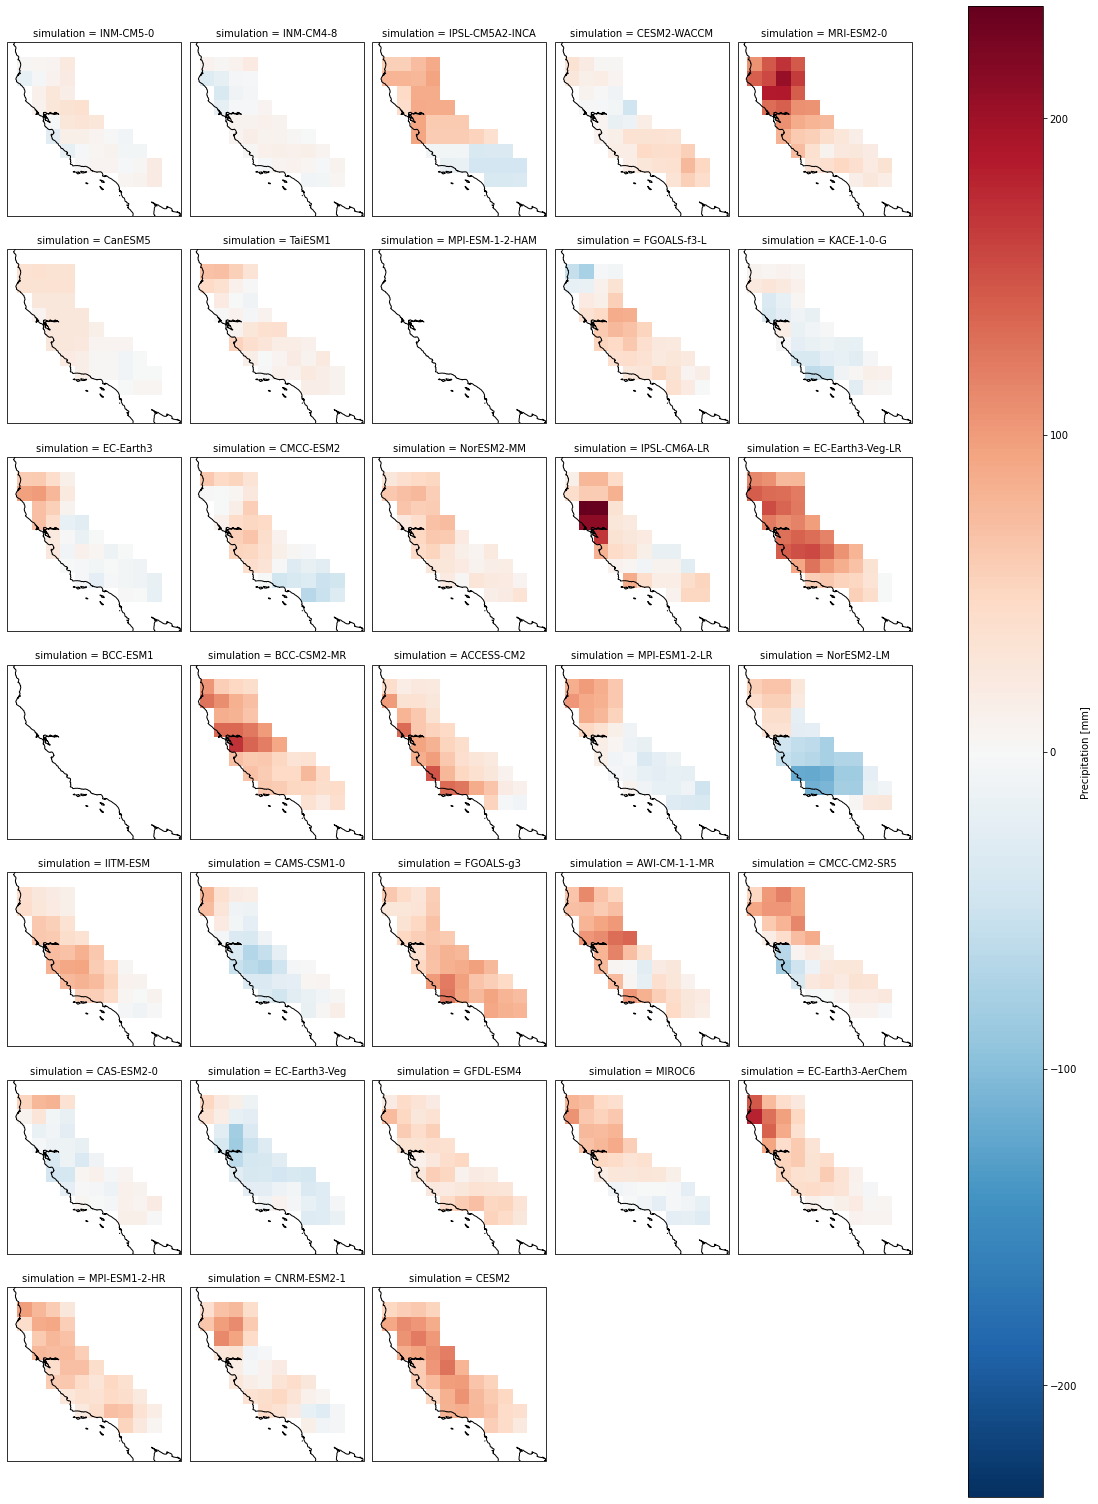

In [128]:
p = delta_percentile.pr.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    col="simulation",
    col_wrap=5,  # multiplot settings
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

# We have to set the map's options on all axes
for ax in p.axes.flat:
    ax.coastlines()
    # ax.add_feature(states110, zorder=1, linewidth=1.5)

    ax.set_extent([-125, -113, 31, 43])

In [129]:
delta_percentile_mmm = delta_percentile.mean(dim="simulation").squeeze()
delta_percentile_mms = delta_percentile.std(dim="simulation").squeeze()

Text(0.5, 1.0, 'Multi-model mean change in 99th percentile')

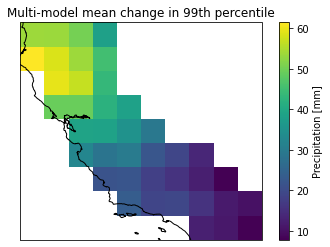

In [130]:


p = delta_percentile_mmm.pr.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('Multi-model mean change in 99th percentile')

Text(0.5, 1.0, 'Multi-model std')

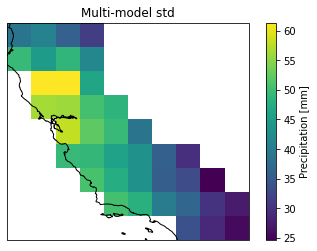

In [131]:


p = delta_percentile_mms.pr.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    # aspect=ds.dims["lon"] / ds.dims["lat"],  # for a sensible figsize
    subplot_kws={"projection": ccrs.PlateCarree()},
)  # the plot's projection

p.axes.coastlines()
p.axes.set_title('Multi-model std')

## Part 1.2: Visualize CMIP6 Model Spread

In [ ]:
hist_max = hist_ds.groupby("time.year").max(dim="time").compute()

ssp_max = ssp_ds.groupby("time.year").max(dim="time").compute()

# multimodel means
hist_mmm = hist_max.mean(dim='simulation').compute()
ssp_mmm = ssp_max.mean(dim='simulation').compute()


In [ ]:
hv.extension('bokeh') # need this here for the plots to show 
ind_color = 'grey'
ssp_color = 'orange'
lw = 0.75
alpha = 0.25

all_hist = hist_max.hvplot.line(x='year', by='simulation',legend=False,
                         line_width=lw, color=ind_color, alpha=alpha)
all_ssp = ssp_max.hvplot.line(x='year', by='simulation',legend=False,
                         line_width=lw, color=ssp_color, alpha=alpha)

mmm_hist = hist_mmm.hvplot.line(x='year', label='historical multi-model mean',
                         line_width=lw*2.5, color='black')
mmm_ssp = ssp_mmm.hvplot.line(x='year', label='SSP3-7.0 multi-model mean',
                         line_width=lw*2.5, color='orange',
                         title="CMIP6 annual maximum monthly "+
                              "precipitation accumulation")

(all_hist * all_ssp * mmm_hist * mmm_ssp).opts(
    legend_position='left',width=900, height=400)

## 1.3: Highlight the Analytics Engine Models

In [ ]:
hist_cae_models = hist_max.sel(simulation=cmip_names).compute()
ssp_cae_models = ssp_max.sel(simulation=cmip_names).compute()

# get model spread
hist_model_min = hist_max.min(dim='simulation').compute(
).rename({'pr':'minimum'})
hist_model_max = hist_max.max(dim='simulation').compute(
).rename({'pr':'maximum'})

hist_spread = xr.merge([hist_model_min,
                       hist_model_max])

ssp_model_min = ssp_max.min(dim='simulation').compute(
).rename({'pr':'minimum'})
ssp_model_max = ssp_max.max(dim='simulation').compute(
).rename({'pr':'maximum'})

ssp_spread = xr.merge([ssp_model_min,
                       ssp_model_max])

cae_models = xr.concat([hist_cae_models,ssp_cae_models],dim='year')

In [ ]:
hist_spread_plot = hist_spread.hvplot.area(y='minimum', y2='maximum',
                                alpha=alpha, color=ind_color,
                                label = 'historical spread')
ssp_spread_plot = ssp_spread.hvplot.area(y='minimum', y2='maximum',
                                alpha=alpha, color=ssp_color,
                                label='SSP3-7.0 spread')
# ?? sometimes will not use the supplied colors ??
cae_plot = cae_models.hvplot.line(x='year', by='simulation',
                         line_width=lw*2, alpha=0.1, 
                        palette=cae_colors_list)
# sometimes will use supplied colors, just have to plot twice
cae_plot_2 = cae_models.hvplot.line(x='year', by='simulation',
                         line_width=lw*2, alpha=alpha*3, 
                        palette=cae_colors_list)

(hist_spread_plot * ssp_spread_plot * mmm_hist * mmm_ssp * cae_plot * cae_plot_2
).opts(legend_position='left', width=900, height=400)

<span style="color:blue"><i>Is the figure too busy for you?</i> Clicking on a legend entry will dim the corresponding graphic.</span>

## Part 1.4: Change in 99th percentile precipitation accumulation
End-of-century (2071-2100) - present-day (1981-2010)

In [ ]:
hist_percentile = hist_ds.sel(
    time=slice('1981','2010')).chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute()

ssp_percentile = ssp_ds.sel(
    time=slice('2071','2100')).chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute()

hist_percentile = hist_percentile.rename(
    dict(quantile='All Models'))
ssp_percentile = ssp_percentile.rename(
    dict(quantile='All Models'))

delta_percentile = (ssp_percentile - hist_percentile).compute()

delta_percentile = delta_percentile.assign_coords(
    {"models":"All CMIP6 models"}).drop(
    "All Models")
     
cmip_percentiles = delta_percentile.sel(
    simulation = cmip_names).assign_coords(
    {"models":"All Cal-Adapt models"}).compute()

indv_percentiles = [cmip_percentiles.sel(simulation=cm
                        ).assign_coords({"models":
                    cm}) for cm in cmip_names] 

indv_percentiles = xr.concat(indv_percentiles,
                             dim="simulation"
                            ).compute()

gcm_percentiles = xr.concat([delta_percentile,
          cmip_percentiles,indv_percentiles],
         dim = 'simulation').compute()

In [ ]:
cmip_delta = gcm_percentiles.hvplot.scatter(
    y='pr',x="models",by='simulation',
    legend=False,title=("CMIP6 multi-model spread"
                        ),
                       alpha=alpha*3,size=300
)

cmip_delta.opts( ylabel=("Change in 99th percentile \n"
        +" monthly precipitation \n accumulation (mm)"))

# Part 2: Internal Variability

## 2.1: Get and process Analytics Engine models

### 2.1.1: First the CMIP6 models

In [ ]:
cat = col.search(
    table_id = "Amon",
    variable_id = 'pr',
    experiment_id = ["historical","ssp370"],
    source_id = cmip_names,
)
dsets = cat.to_dataset_dict(zarr_kwargs={'consolidated': True}, 
                            storage_options={'anon': True},
                           preprocess=wrapper
                           )

# Subsets the historical scenario
hist_dsets = {key: val for key,val in dsets.items()
             if "historical" in key}

# Subsets the future scenario
ssp_dsets = {key: val for key,val in dsets.items()
               if "ssp370" in key}

hist_cae_ds = xr.concat(
    list(hist_dsets.values()),
    dim='simulation').squeeze()
hist_cae_ds = copt.cmip_clip(
    hist_cae_ds)

ssp_cae_ds = xr.concat(
    list(ssp_dsets.values()),
    dim='simulation').squeeze()
ssp_cae_ds = copt.cmip_clip(
    ssp_cae_ds)


### 2.1.2: Then get their downscaled counterparts

In [ ]:
cmip_wrf_members = {
    "CESM2": "r11i1p1f1",
    "CNRM-ESM2-1": "r1i1p1f2",
    "EC-Earth3-Veg": "r1i1p1f1",
    "FGOALS-g3": "r1i1p1f1",
    # "MPI-ESM1-2-LR": "r7i1p1f1",
}
wrf_max = wrf_ds.groupby("time.year").max(dim="time").squeeze().compute()

hist_cae_max = hist_cae_ds.groupby("time.year").max(dim="time").compute()
hist_cae_wrf_member = hist_cae_max.sel(
    member_id = list(cmip_wrf_members.values()))

ssp_cae_max = ssp_cae_ds.groupby("time.year").max(dim="time").compute()
ssp_cae_wrf_member = ssp_cae_max.sel(
    member_id = list(cmip_wrf_members.values()))

## 2.2: Show the spread across ensemble members, including the downscaled data
<b>Why do this?</b>
- Each of the four Cal-Adapt models highlighted here was run a number of times (recall that each run is called an <i>ensemble member</i>). 
    - The difference across ensemble members represents the internal variability - that is, the difference in a model's output which occurs as a result of the fact that <b>climate is inherently chaotic</b>.  
    - If we assume that a model captures the relevant physical processes, <b>each ensemble member can then be considered an equally probable future.</b> In other words, capturing a model's internal variability provides an analog for natural background variability in the climate system. 
- One ensemble member from each of the Cal-Adapt models was downscaled in order to capture finer-scale processes. Here we show how these downscaled members fit within the larger Cal-Adapt ensemble.

In [ ]:
# hv.extension('bokeh')
ind_color = 'grey'
ssp_color = 'orange'
lw = 0.75
alpha = 0.25

hist_cae_max_plt = hist_cae_max.sel(year=slice(1981,2014)).hvplot.line(
                        x='year', by='member_id',
                         line_width=lw, color=ind_color, alpha=alpha*3,
                        legend=False)
ssp_cae_max_plt = ssp_cae_max.sel(year=slice(2015,2100)).hvplot.line(
                        x='year', by='member_id',
                         line_width=lw, color=ssp_color, alpha=alpha*3,
                        legend=False)

hist_cae_member = hist_cae_wrf_member.sel(year=slice(1981,2014)).mean(
                        dim='member_id').hvplot.line(x='year',  
                        line_width=lw*2, color='black', alpha=alpha*3,
                        label = "Corresponding CMIP6 ensemble member")
ssp_cae_member = ssp_cae_wrf_member.sel(year=slice(2015,2100)).mean(
                        dim='member_id').hvplot.line(x='year',  
                        line_width=lw*2, color='black', alpha=alpha*3,
                        label = "Corresponding CMIP6 ensemble member")

hist_wrf_member = wrf_max.sel(year=slice(1981,2014)).squeeze(
                        ).hvplot.line(x='year',  
                        line_width=lw*2, color='blue', alpha=alpha*3,
                        label = "Downscaled member")
ssp_wrf_member = wrf_max.sel(year=slice(2015,2100)).squeeze(
                        ).hvplot.line(x='year',  
                        line_width=lw*2, color='blue', alpha=alpha*3,
                        label = "Downscaled member",
                        title="Ensemble spread for given model (select on right)")

(hist_cae_max_plt *  ssp_cae_max_plt * hist_wrf_member 
 * ssp_wrf_member * hist_cae_member * ssp_cae_member).opts(
    legend_position='top',width=900, height=400) 

- Grey lines (left): Historical ensemble members
- Yellow lines (right): SSP3-7.0 ensemble members

Note: Selecting the 'simulation' on the right of the graphic can take some time to update the plot

<span style="color:red">Note for our in-house reviewers: Need to find a way to have one label for all the lines which make up each ensemble member (in black and yellow). currently it labels each one - a huge mess! could also show as shading, like in a previous figure.</span> 


In [ ]:
# percentile for the cal-adapt GCMs (together)
pd_cae_ds = hist_cae_ds.sel(
    time=slice('1981','2010'))
eoc_cae_ds = ssp_cae_ds.sel(time=slice(
    '2071','2100'))
pd_cae_percentile = pd_cae_ds.chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute()
eoc_cae_percentile = eoc_cae_ds.chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute()
pd_cae_percentile = pd_cae_percentile.rename(
    dict(quantile='All Models'))
eoc_cae_percentile = eoc_cae_percentile.rename(
    dict(quantile='All Models'))
cae_delta_percentile = (eoc_cae_percentile 
                    - pd_cae_percentile).compute()

In [ ]:
# pull out individual Cal-Adapt GCMs
cae_delta_percentile = cae_delta_percentile.assign_coords(
    {"models":"Cal-Adapt ensemble members"}).drop(
    "All Models")

# percentile for the cal-adapt GCMs (individually)
cae_indv_percentiles = [cae_delta_percentile.sel(
                    simulation=cm).assign_coords({"models":
                    cm}) for cm in cmip_names] 
cae_indv_percentiles = xr.concat(cae_indv_percentiles,
                        dim="simulation").compute()
cae_percentiles = xr.concat([cae_delta_percentile,
                    cae_indv_percentiles],
                    dim = 'simulation').compute()

cae_medians = cae_indv_percentiles.quantile(
    [.5],dim='member_id').compute()


In [ ]:
# subset Cal-Adapt ensemble members which were downscaled via WRF
cae_wrf_member_ptiles = cae_indv_percentiles.sel(
    member_id = list(cmip_wrf_members.values()))

# now do it for the WRF models
pd_wrf_ds = wrf_ds.sel(
    time=slice('1981','2010'))
eoc_wrf_ds = wrf_ds.sel(time=slice(
    '2071','2100'))
pd_wrf_percentile = pd_wrf_ds.chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute()
eoc_wrf_percentile = eoc_wrf_ds.chunk(dict(
    time=-1)).quantile([.99],
    dim='time').compute()
pd_wrf_percentile = pd_wrf_percentile.rename(
    dict(quantile='All Models'))
eoc_wrf_percentile = eoc_wrf_percentile.rename(
    dict(quantile='All Models'))
wrf_delta_percentile = (eoc_wrf_percentile 
                    - pd_wrf_percentile).compute()

wrf_delta_percentile = wrf_delta_percentile.assign_coords(
    {"models":"Cal-Adapt ensemble members"}).drop(
    "All Models")

# percentile for the WRF models (individually)
wrf_indv_percentiles = [wrf_delta_percentile.sel(
                    simulation=cm).assign_coords({"models":
                    cm}) for cm in cmip_names] 
wrf_indv_percentiles = xr.concat(wrf_indv_percentiles,
                        dim="simulation").compute()

wrf_delta_percentile= xr.concat([wrf_delta_percentile,
                    wrf_indv_percentiles],
                    dim = 'simulation').compute()

In [ ]:
cae_delta = cae_percentiles.hvplot.scatter(
    y='pr',x="models",by='member_id',alpha=alpha*2,
    legend=False,title="Ensemble member spread in Cal-Adapt models",
    color='#ddaa33',marker='hex',size=150
)

cae_med = cae_medians.hvplot.scatter(
    y='pr',x="models",by='quantile',alpha=1,
    legend=False,title="Ensemble member spread in Cal-Adapt models",
    color='k',marker='dash',size=600
)

wrf_member_delta = cae_wrf_member_ptiles.hvplot.scatter(
    y='pr',x="models",by='member_id',alpha=alpha*3,color='#004488',
    marker = 'triangle',legend=False,size=300
)

wrf_ptile_delta = wrf_delta_percentile.hvplot.scatter(
    x="models",by='simulation',alpha=1,fill_color='w',
    marker='star',legend=False,size=300,
)

(cae_delta  * cae_med * wrf_member_delta * wrf_ptile_delta).opts(
    legend_position='top',
    ylabel=("Change in 99th percentile \n"
        +" monthly precipitation \n accumulation (mm)")
) 

- Yellow hexagons: Cal-Adapt ensemble member
- White stars: Downscaled (WRF) member
- Blue triangles: Original Cal-Adapt member which was downscaled via WRF ("parent" model data)
- Long dashes: Ensemble median for given model

<span style="color:red">Note for our in-house reviewers: Similar to before, need to find a way to have one label for all the identical markers. I also do notice the bugs whereby it is plotting some triangles twice.</span> 


<span style="color:red">Additional note: sceintific guidance is coming.</span> 
